# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>1.1 Introduction 
Loan approval is a critical decision-making process for financial institutions. Incorrect approvals can lead to significant financial losses due to borrower defaults.

This project presents a **Loan Approval Prediction System** that leverages historical loan data to estimate the **risk of default**. Instead of directly predicting approval, the system predicts whether a borrower is likely to default and uses this insight to make approval decisions.
- **Low default risk → Loan Approved ✅**
- **High default risk → Loan Not Approved ❌**

Machine learning models such as **Random Forest** and **XGBoost** are used to capture complex patterns in borrower data and improve prediction accuracy.</b></div>

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>1.2 Problem Statement 
Given a dataset of loan applicants, including demographic, financial, and loan-specific features, the goal is to predict whether a borrower will default (loan_status). Early prediction of default can help lenders minimize financial risk.</b></div>

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>1.3 Data set Info
</b></div>

### Target Variable:
- **loan_status**: Indicates whether the borrower defaulted (1 = Default, 0 = No Default)

### Categorical Features:
- **person_home_ownership**: Type of home ownership (e.g., RENT, OWN, MORTGAGE)
- **loan_intent**: Purpose of the loan (e.g., EDUCATION, MEDICAL, PERSONAL, HOMEIMPROVEMENT)
- **loan_grade**: Risk grade assigned to the loan by lender (A to G)
- **cb_person_default_on_file**: Whether the borrower has any prior default on file (Y/N)

### Numerical Features:
- **person_age**: Age of the borrower (years)
- **person_income**: Annual income of the borrower (USD)
- **person_emp_length**: Years of employment
- **loan_amnt**: Loan amount requested (USD)
- **loan_int_rate**: Interest rate of the loan (%)
- **loan_percent_income**: Loan amount as a percentage of borrower’s income
- **cb_person_cred_hist_length**: Length of borrower’s credit history 



# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>1.4 Data Load and Check</b></div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../Dataset/credit_risk_data.csv')
df.head()


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0.0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1.0,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2.0,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3.0,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4.0,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [3]:
print("Shape:", df.shape)

display(df.head())

display(df.info())

display(df.describe())



Shape: (91226, 13)


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0.0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1.0,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2.0,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3.0,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4.0,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91226 entries, 0 to 91225
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  float64
 1   person_age                  91226 non-null  int64  
 2   person_income               91226 non-null  int64  
 3   person_home_ownership       91226 non-null  object 
 4   person_emp_length           90331 non-null  float64
 5   loan_intent                 91226 non-null  object 
 6   loan_grade                  91226 non-null  object 
 7   loan_amnt                   91226 non-null  int64  
 8   loan_int_rate               88110 non-null  float64
 9   loan_percent_income         91226 non-null  float64
 10  cb_person_default_on_file   91226 non-null  object 
 11  cb_person_cred_hist_length  91226 non-null  int64  
 12  loan_status                 91226 non-null  int64  
dtypes: float64(4), int64(5), object

None

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,91226.000000,9.122600e+04,90331.000000,91226.000000,88110.000000,91226.000000,91226.000000,91226.000000
mean,29322.000000,27.616480,6.477071e+04,4.732119,9350.348607,10.789508,0.163154,5.810219,0.169447
std,16929.497605,6.148115,4.793696e+04,4.025068,5848.605423,3.108998,0.097491,4.038412,0.375149
min,0.000000,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.000000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.700000e+04,4.000000,8000.000000,10.950000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.800000e+04,7.000000,12000.000000,13.110000,0.220000,8.000000,0.000000
max,58644.000000,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


## Null Check

In [4]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
id                            32581
person_age                        0
person_income                     0
person_home_ownership             0
person_emp_length               895
loan_intent                       0
loan_grade                        0
loan_amnt                         0
loan_int_rate                  3116
loan_percent_income               0
cb_person_default_on_file         0
cb_person_cred_hist_length        0
loan_status                       0
dtype: int64


In [5]:
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

print("\nMissing values after imputation:")
print(df[['loan_int_rate','person_emp_length']].isnull().sum())


Missing values after imputation:
loan_int_rate        0
person_emp_length    0
dtype: int64


## Duplicate Check

In [6]:

df_no_id = df.drop(columns=["id"])
num_duplicates = df_no_id.duplicated().sum()
df = df.drop_duplicates(subset=df_no_id.columns, keep='first')
print("Number of duplicate rows Before :", num_duplicates)
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows After :", num_duplicates)

Number of duplicate rows Before : 166
Number of duplicate rows After : 0


## Range Check

In [7]:

ranges = {
    "person_age": (18, 80),
    "person_income": (0, 1_000_000),  
    "person_emp_length": (0, 60),     
    "loan_amnt": (500, 50_000),   
    "loan_int_rate": (5, 25),           
    "loan_percent_income": (0, 1),     
    "cb_person_cred_hist_length": (0, 40),  
    "loan_status": (0, 1)              
}

print("\n🔢 Checking numerical values range...\n")

for col, (low, high) in ranges.items():
    if col in df.columns:
        
        outliers = df[(df[col] < low) | (df[col] > high)][col]
        if not outliers.empty:
            print(f"⚠️ {col} out of range values: {outliers.unique()}\n")
        else:
            print(f"✅ {col} is within range")


🔢 Checking numerical values range...

⚠️ person_age out of range values: [ 84 123 144  94]

⚠️ person_income out of range values: [1200000 1839784 1900000 1824000 2039784 1362000 1440000 6000000 1782000]

⚠️ person_emp_length out of range values: [123.]

✅ loan_amnt is within range
✅ loan_int_rate is within range
✅ loan_percent_income is within range
✅ cb_person_cred_hist_length is within range
✅ loan_status is within range


#### Data Cleaning Decision:

**Person Age:** A few borrowers had ages like 123 and 144, which are 
clearly impossible and were removed. Ages like 84 and 94, while not 
impossible, are outside the typical range of loan applicants this model 
is built for. 

**Employment Length:** One record showed an employment length of 123 years, 
which is obviously wrong. It was removed.

In total, only 14 rows were removed out of 91,060 which is less than 0.02% 
of the data, so this has no real impact on the model.

**Person Income:** Some borrowers showed very high incomes, up to $6M. 
These were kept because they could be real — some people genuinely earn 
that much. Instead of removing them, a log transformation was applied 
to income during feature engineering, which prevents these large numbers 
from having an outsized influence on the model.

In [8]:
print("Before  removal:", df.shape)
df=df[df['person_age'] <= 80]
df=df[df['person_emp_length'] <= 60]
print("After  removal:", df.shape)

Before  removal: (91060, 13)
After  removal: (91046, 13)


In [9]:

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(['id']).tolist()

print("Categorical Columns:", cat_cols)
print("Numerical Columns:", num_cols)

Categorical Columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
Numerical Columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status']


# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>1.5 Univariate Analysis
</b></div>

## Target value distribution

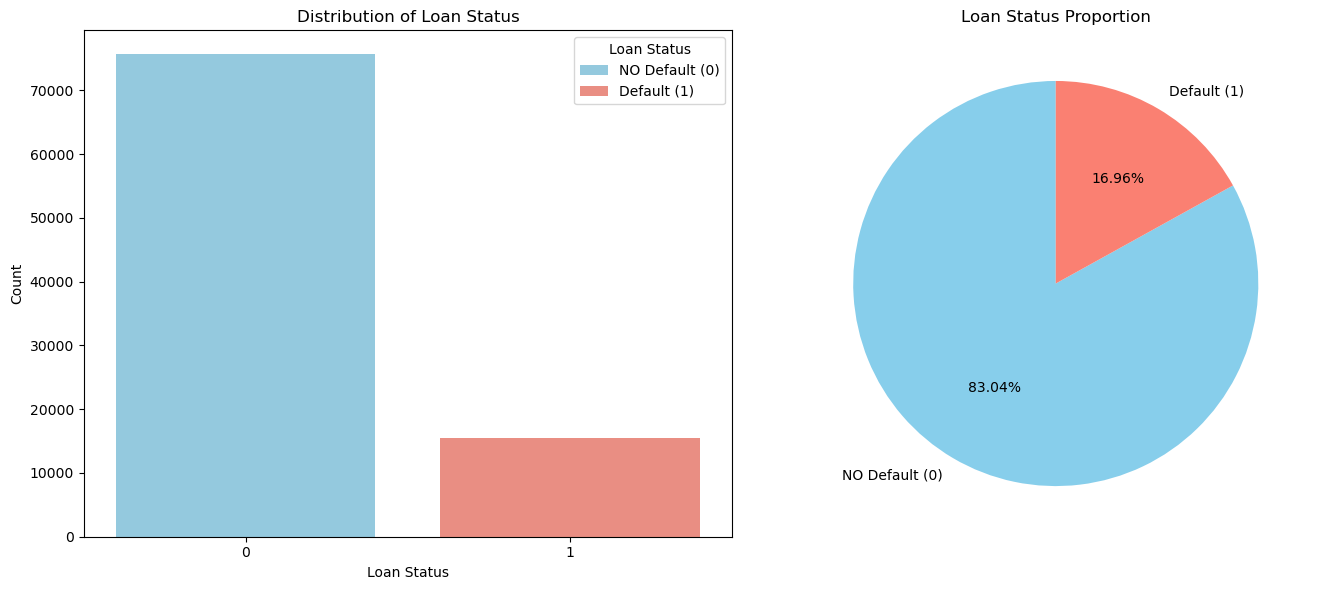

In [10]:
fig , axes = plt.subplots(1,2, figsize=(14,6))

colors = ['skyblue', 'salmon']
sns.countplot(data=df,x='loan_status', ax=axes[0], palette=colors,hue='loan_status')
axes[0].set_title('Distribution of Loan Status')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')
axes[0].legend(title='Loan Status', labels=['NO Default (0)', 'Default (1)'])

status_counts = df['loan_status'].value_counts().sort_index()
axes[1].pie(status_counts, labels=["NO Default (0)", "Default (1)"], autopct='%1.2f%%', colors=colors, startangle=90)
axes[1].set_title('Loan Status Proportion')

plt.tight_layout()
plt.show()


Observation: The dataset is imbalanced, with almost 83% of loans in good standing and a 17% default rate,

## Distribution of Numerical Features

In [11]:
df[num_cols].describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,91046.000000,9.104600e+04,91046.000000,91046.000000,91046.000000,91046.000000,91046.000000,91046.000000
mean,27.611372,6.470196e+04,4.720021,9350.869912,10.796358,0.163158,5.811974,0.169552
std,6.076881,4.369258e+04,3.929630,5847.105701,3.056161,0.097474,4.037645,0.375241
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,23.000000,4.000000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,26.000000,5.700000e+04,4.000000,8000.000000,10.950000,0.140000,4.000000,0.000000
75%,30.000000,7.800000e+04,7.000000,12000.000000,13.040000,0.220000,8.000000,0.000000
max,80.000000,2.039784e+06,41.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


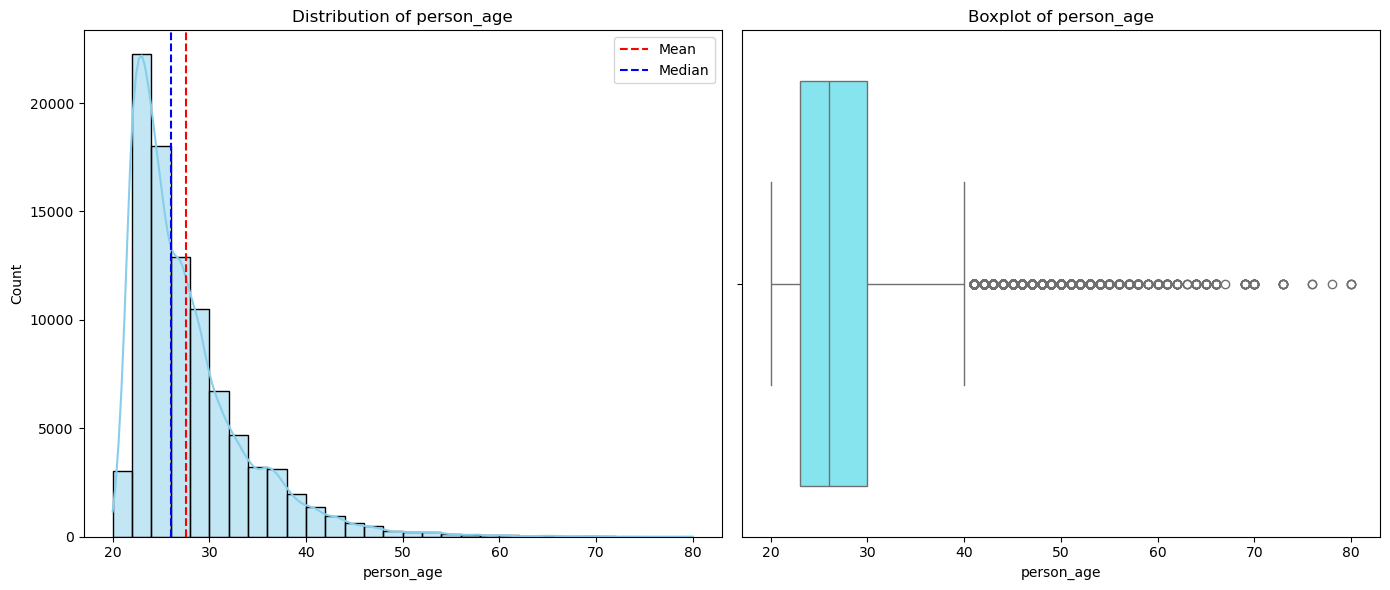

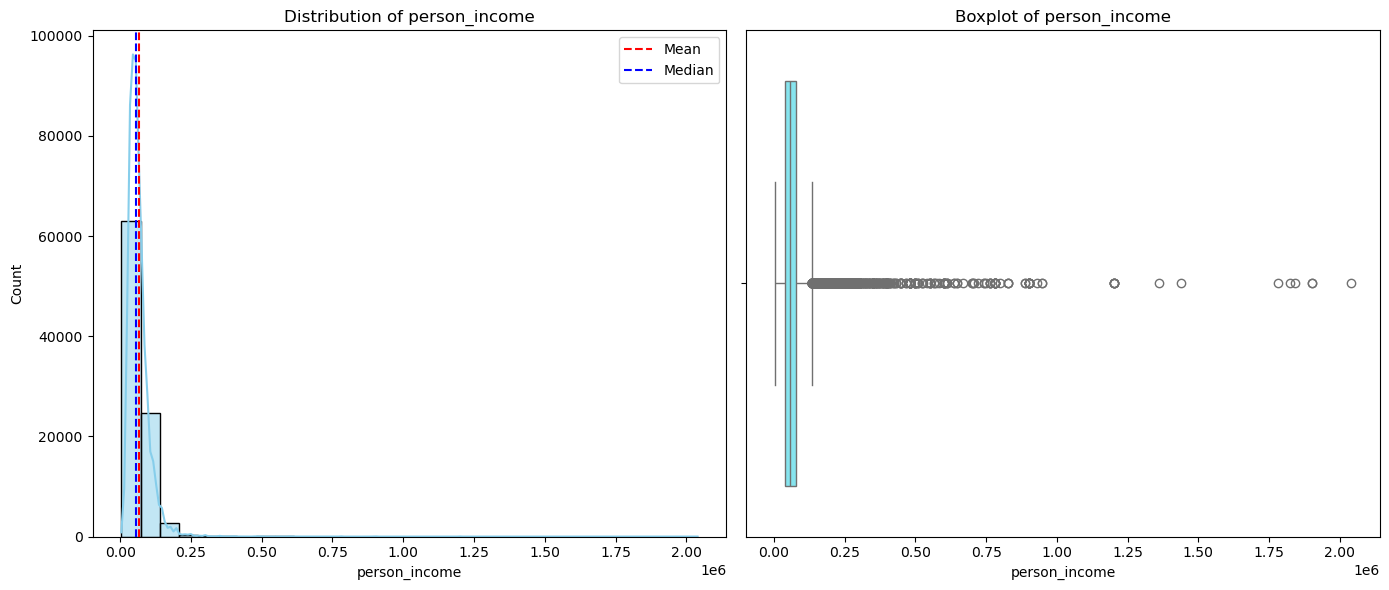

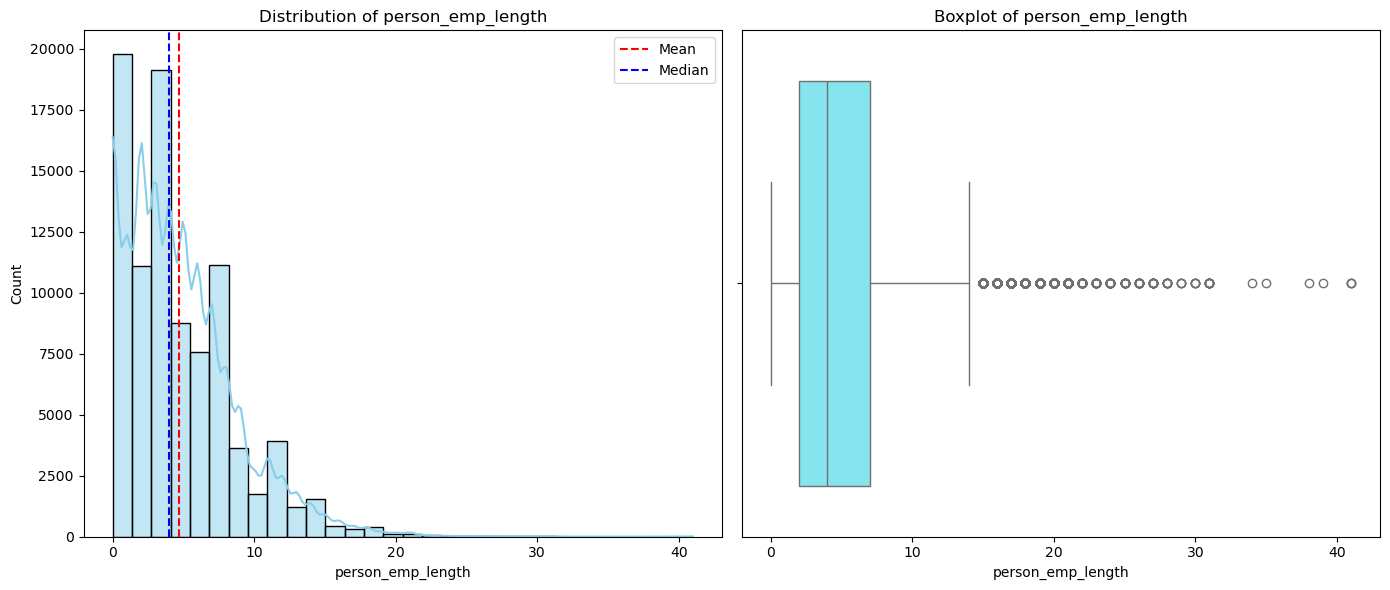

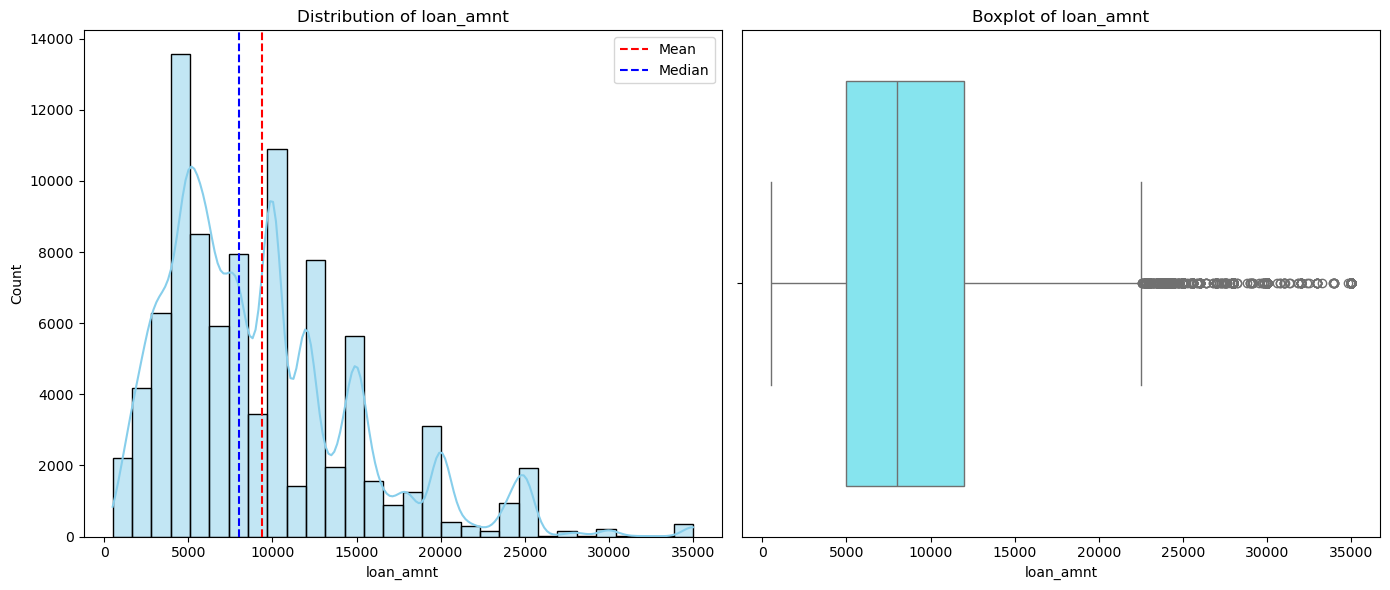

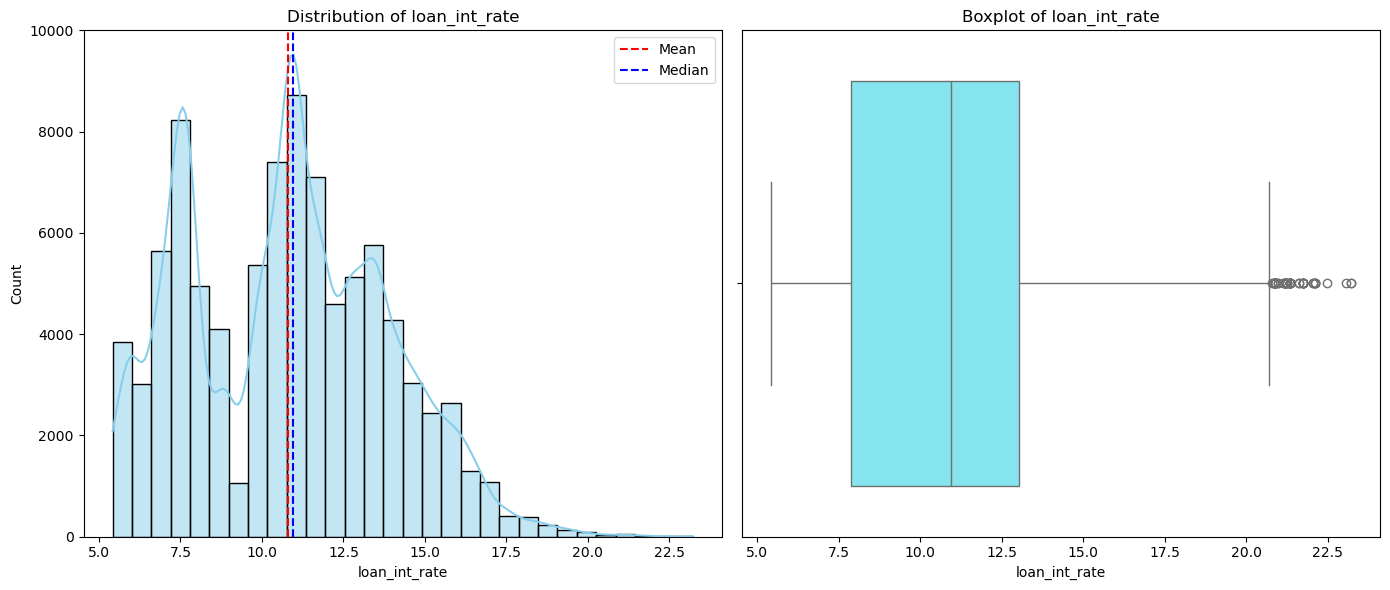

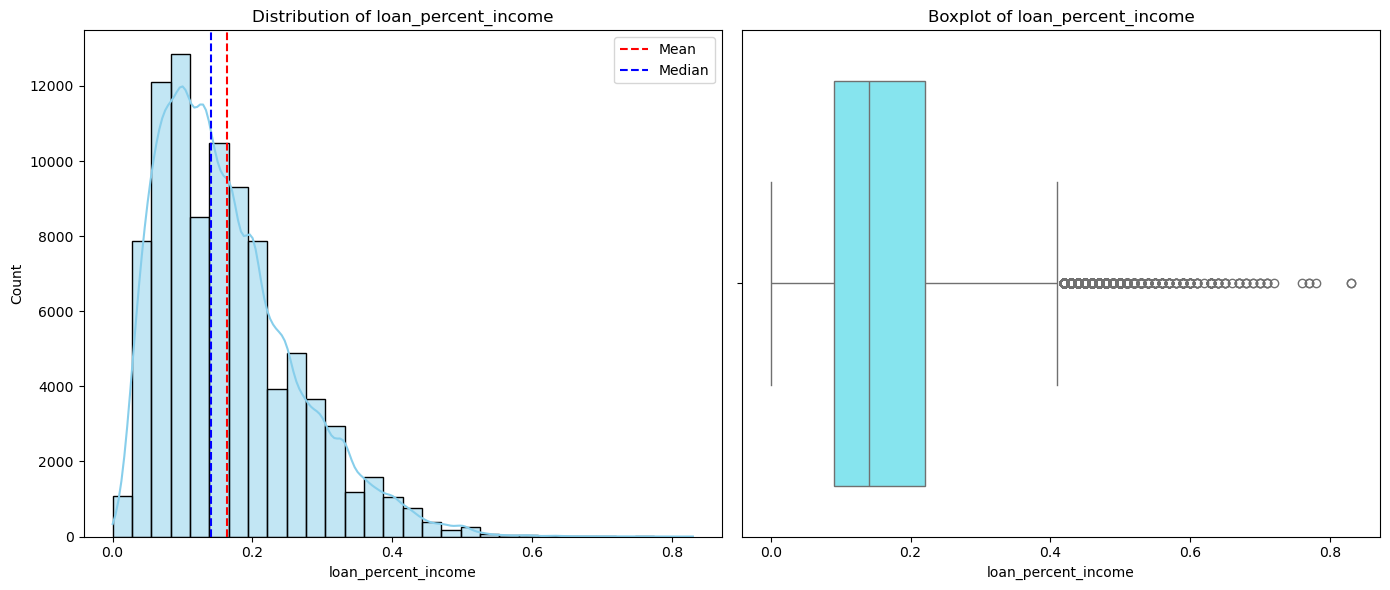

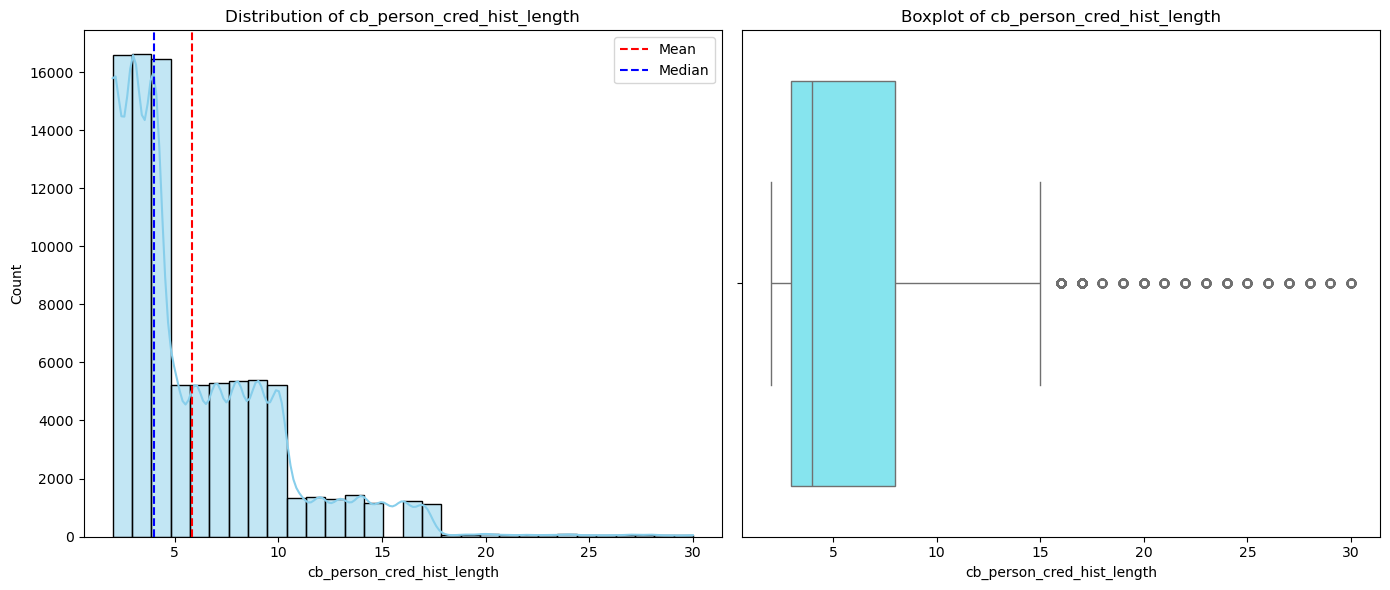

In [12]:
num_cols = [
'person_age','person_income','person_emp_length','loan_amnt','loan_int_rate',
'loan_percent_income','cb_person_cred_hist_length'
]

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    
    # Histogram
    sns.histplot(data=df, x=col, kde=True, ax=axes[0], color='skyblue',bins=30)
    
    mean_value = df[col].mean()
    median_value = df[col].median()
    
    axes[0].axvline(mean_value, color='red', linestyle='--', label="Mean")
    axes[0].axvline(median_value, color='blue', linestyle='--', label="Median")
    
    axes[0].set_title(f'Distribution of {col}')
    axes[0].legend()
    
    # Boxplot (fixed color)
    sns.boxplot(data=df, x=col, color='#75F2FF', ax=axes[1])
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

## Distribution of Categorical Features

In [13]:
df[cat_cols].describe()

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,91046,91046,91046,91046
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,46967,18680,31683,76616


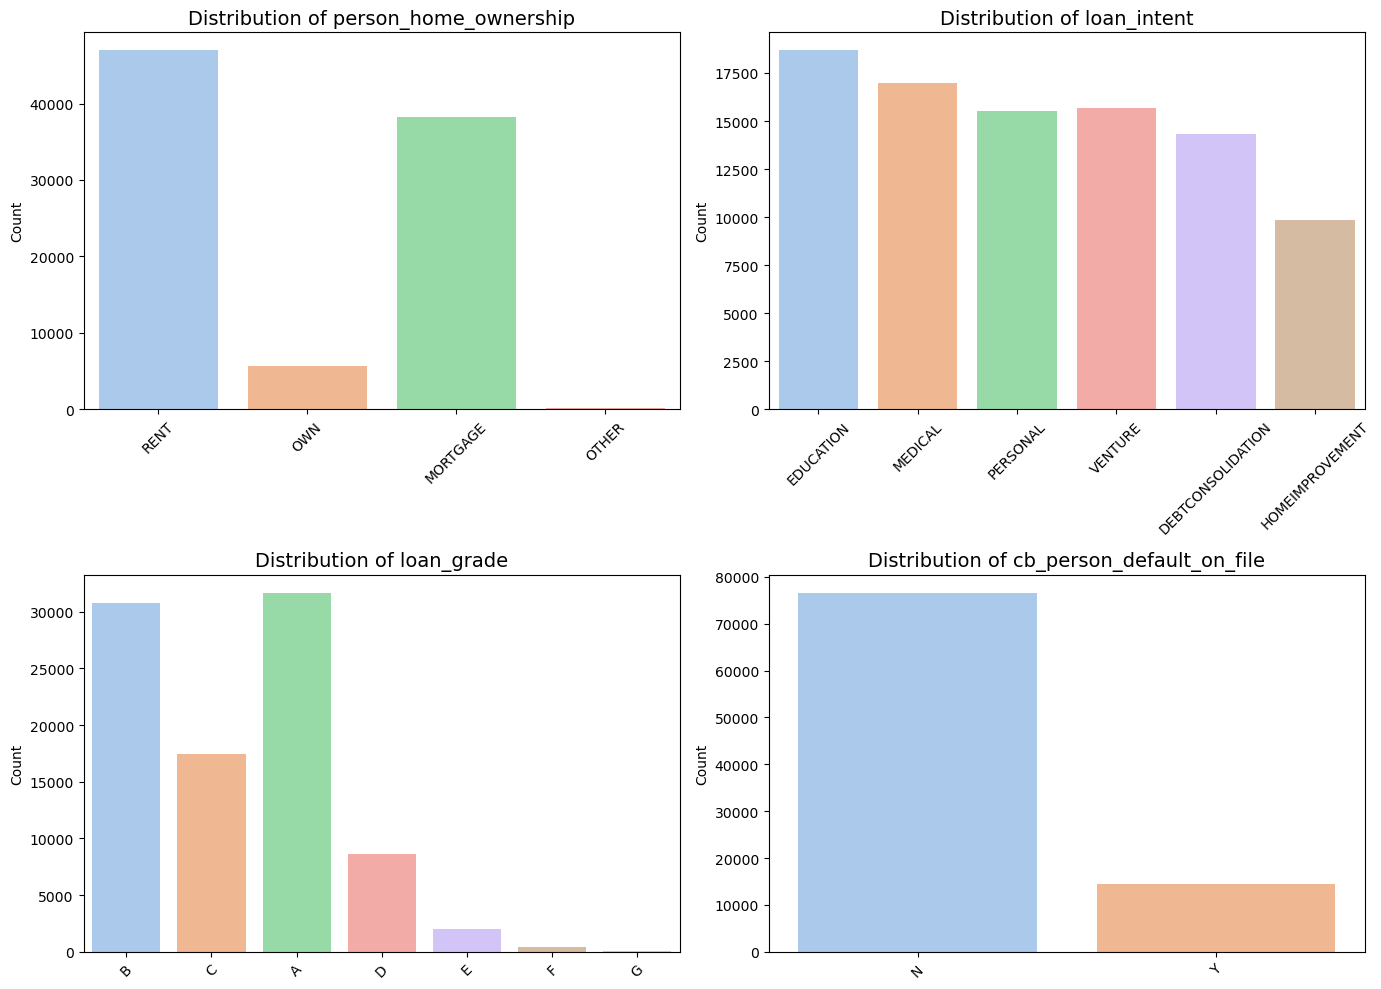

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  #

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, palette='pastel', ax=axes[i],hue=col)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()

# <div style="text-align:center; border-radius:15px; padding:15px; margin:0; font-size:100%; font-family: 'Arial Black', Arial, sans-serif; text-shadow: 2px 2px 5px rgba(0,0,0,0.7); background: linear-gradient(90deg, #0f2027, #203a43, #2c5364); overflow:hidden; box-shadow:0 2px 5px rgba(0, 0, 0, 0.3); color:white;"><b>1.6 Multivariate Analysis
</b></div>

## Loan Default Risk Across Categorical Features

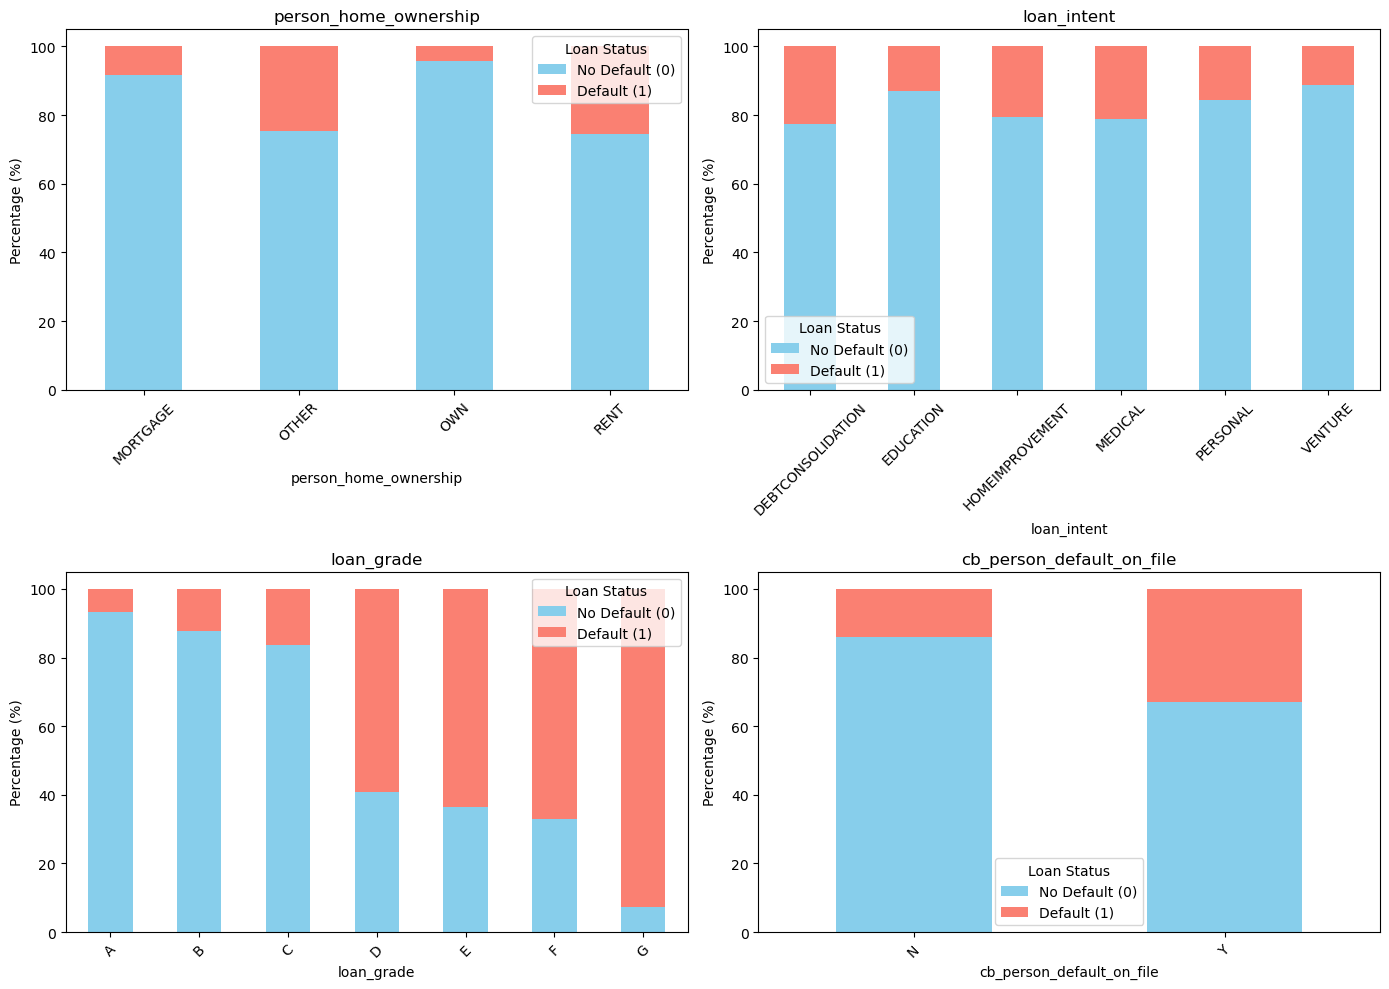

In [15]:



fig, axes = plt.subplots(2,2, figsize=(14,10))
axes = axes.ravel()

for i,col in enumerate(cat_cols):
    
    temp = pd.crosstab(df[col], df['loan_status'], normalize='index') * 100
    temp.plot(kind='bar', stacked=True, ax=axes[i],color=['skyblue', 'salmon'])
    
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel("Percentage (%)")
    axes[i].legend(title='Loan Status', labels = ['No Default (0)', 'Default (1)'])

plt.tight_layout()
plt.show()

### Some key insights: 
<div style="background-color: #11111b; padding: 20px; border-radius: 12px; border: 1px solid #313244; color: #cdd6f4; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; width: 95%; margin: 10px auto;">

<table style="width: 100%; border-collapse: collapse; table-layout: auto;">
<thead>
<tr style="border-bottom: 3px solid #45475a;">
<th style="text-align: left; padding: 12px; color: #89b4fa; font-size: 1.1em;">Category</th>
<th style="text-align: left; padding: 12px; color: #a6e3a1; font-size: 1.1em;">Low Risk ✅</th>
<th style="text-align: left; padding: 12px; color: #fab387; font-size: 1.1em;">Moderate ⚠️</th>
<th style="text-align: left; padding: 12px; color: #f38ba8; font-size: 1.1em;">High Risk 🚨</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom: 1px solid #313244;">
<td style="padding: 15px;"><b>🏠 Home Ownership</b></td>
<td style="padding: 15px;">OWN</td>
<td style="padding: 15px;">MORTGAGE</td>
<td style="padding: 15px;">RENT</td>
</tr>
<tr style="border-bottom: 1px solid #313244;">
<td style="padding: 15px;"><b>🎯 Loan Purpose</b></td>
<td style="padding: 15px;">Education / Venture</td>
<td style="padding: 15px;">Home Improvement</td>
<td style="padding: 15px;">Medical / Debt Consolidation</td>
</tr>
<tr style="border-bottom: 1px solid #313244;">
<td style="padding: 15px;"><b>📉 Loan Grade</b></td>
<td style="padding: 15px;">A & B (Prime)</td>
<td style="padding: 15px;">C (Mid-tier)</td>
<td style="padding: 15px;">D, E, F, G (Subprime)</td>
</tr>
<tr>
<td style="padding: 15px;"><b>🚩 Default History</b></td>
<td style="padding: 15px;">No (N)</td>
<td style="padding: 15px;">—</td>
<td style="padding: 15px; color: #f38ba8;"><b>Yes (Y) - Critical Flag</b></td>
</tr>
</tbody>
</table>

<div style="margin-top: 20px; padding: 15px; background-color: #181825; border-left: 5px solid #f38ba8; border-radius: 4px; font-size: 1em; line-height: 1.6;">
<strong style="color: #f38ba8;">Final Insight:</strong> Borrowers with higher loan burden, higher interest rates, lower credit grades, and previous defaults are more likely to default. In contrast, individuals with stable income, longer credit history, and home ownership tend to be safer.
</div>

</div>

## Linear Feature Correlation Matrix

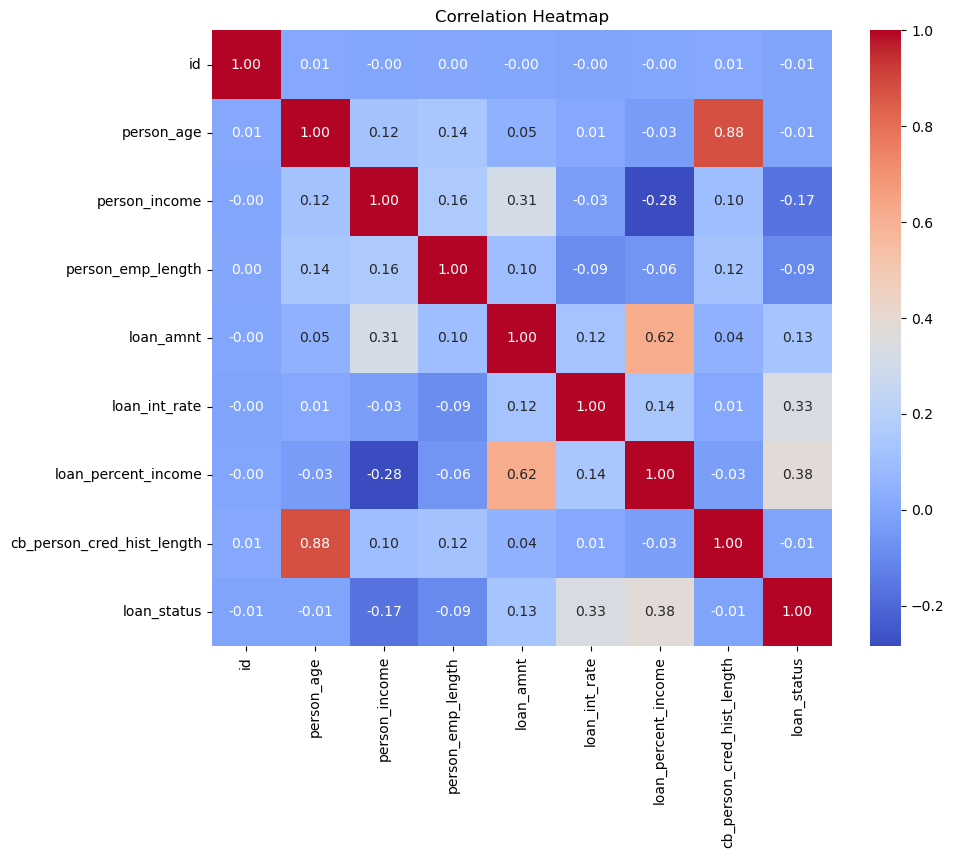

In [16]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

| Feature / Relationship                          | Correlation | Insight                                       |
| ----------------------------------------------- | ----------- | --------------------------------------------- |
| loan_percent_income → loan_status               | +0.38       | Higher loan burden increases default risk     |
| loan_int_rate → loan_status                     | +0.33       | Higher interest rates lead to higher defaults |
| person_income → loan_status                     | -0.17       | Higher income slightly reduces default risk   |
| person_age, emp_length, cred_hist → loan_status | ~0          | Weak impact individually                      |
| person_age ↔ cred_hist_length                   | +0.88       | Strong correlation → possible redundancy      |


In [17]:
df.drop(columns=['id'], inplace=True)
df.to_csv('../Dataset/credit_risk_data_cleaned.csv', index=False)
print(f'Saved cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns')
print('Columns:', df.columns.tolist())

Saved cleaned dataset: 91046 rows, 12 columns
Columns: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'loan_status']
